<a href="https://colab.research.google.com/github/Adossi-design/Malaria-Diagnosis/blob/main/Berissa_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Problem Framing and Literature Review

**Why malaria diagnosis needs AI**

Malaria is one of the most dangerous diseases in the world. The World Health Organization reported over 249 million cases and more than 600,000 deaths in 2022, with most deaths happening in children under five years old in Africa (WHO, 2023). The standard way to diagnose malaria is to look at a blood smear slide under a microscope. A trained technician checks for the Plasmodium parasite inside red blood cells. This method is accurate when done well, but it is very slow, tiring, and expensive. In many rural areas of Africa, there are not enough trained technicians, so patients wait a long time for a diagnosis. Automating this process with deep learning could save lives by making diagnosis faster and cheaper.

**Convolutional Neural Networks for image classification**

LeCun et al. (1998) showed that Convolutional Neural Networks can learn visual features directly from raw pixel values using gradient-based training. This was a major advance because it removed the need for hand-crafted feature engineering. Since then, CNNs have become the standard approach for image classification. Simonyan and Zisserman (2014) introduced VGG16 and showed that using many small 3x3 filters in a deep network gives better results than using fewer large filters. VGG16 achieved state-of-the-art performance on ImageNet and became very popular for transfer learning. He et al. (2016) introduced ResNet, which uses skip connections to let gradients pass directly through layers without disappearing. This solved the vanishing gradient problem and allowed networks of 50 or more layers to train well. Sandler et al. (2018) introduced MobileNetV2, which uses depthwise separable convolutions and inverted residual blocks to achieve competitive accuracy with far fewer parameters. MobileNetV2 is especially useful in resource-limited settings like hospitals in rural Africa where computing power is limited.

**Transfer learning in medical imaging**

Pan and Yang (2010) defined transfer learning as using knowledge from one domain to help learning in a different domain. In medical imaging, this is very useful because medical datasets are usually small and expensive to label. Tajbakhsh et al. (2016) showed that fine-tuning pretrained CNNs on medical images gives much better results than training from scratch, especially when the dataset has fewer than 50,000 images. Our dataset from the NIH (National Institutes of Health) has about 27,000 cell images, which is a situation where transfer learning is strongly recommended.

**Malaria detection with CNNs**

Rajaraman et al. (2018) directly tested several pretrained CNNs on the NIH malaria cell dataset. They found that VGG16 achieved over 95% accuracy on parasitized vs. uninfected cell classification. Their work directly motivates our choice of VGG16, ResNet50, and MobileNetV2 in this project. They also showed that fine-tuning beats pure feature extraction for this task, which is why we run experiments with progressive layer unfreezing.

**Regularization techniques**

Srivastava et al. (2014) introduced dropout, which randomly sets a fraction of activations to zero during training. This stops neurons from relying too much on each other and reduces overfitting. Ioffe and Szegedy (2015) introduced Batch Normalization, which normalizes activations within each mini-batch during training. This reduces internal covariate shift, speeds up convergence, and also acts as a regularizer. These two techniques are used in our baseline and advanced CNN experiments.

**Connection to this project**

Each model in our group is grounded in the literature above. Adossi's baseline CNN follows the standard Conv-Pool-Dense structure from LeCun et al. (1998). Nehemie's advanced CNN adds Batch Normalization from Ioffe and Szegedy (2015) and Dropout from Srivastava et al. (2014). Berissa uses VGG16 from Simonyan and Zisserman (2014) with the fine-tuning strategy recommended by Rajaraman et al. (2018). Elvin uses ResNet50 from He et al. (2016) with frozen BatchNormalization layers following best practices for ResNet fine-tuning. Gabriel uses MobileNetV2 from Sandler et al. (2018), which is the most practical model for real-world deployment in low-resource clinical settings.

**References**

- He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *CVPR*, 770-778.
- Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *ICML*, 448-456.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278-2324.
- Pan, S. J., & Yang, Q. (2010). A survey on transfer learning. *IEEE Transactions on Knowledge and Data Engineering*, 22(10), 1345-1359.
- Rajaraman, S., Antani, S. K., Poostchi, M., Silamut, K., Hossain, M. A., Maude, R. J., & Jaeger, S. (2018). Pre-trained convolutional neural networks as feature extractors toward improved malaria parasite detection in thin blood smear images. *PeerJ*, 6, e4568.
- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. *CVPR*, 4510-4520.
- Simonyan, K., & Zisserman, A. (2014). Very deep convolutional networks for large-scale image recognition. *ICLR*.
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Drozdov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *JMLR*, 15(1), 1929-1958.
- Tajbakhsh, N., et al. (2016). Convolutional neural networks for medical image analysis: Full training or fine tuning? *IEEE Transactions on Medical Imaging*, 35(5), 1299-1312.
- WHO. (2023). *World Malaria Report 2023*. World Health Organization.

## Configuration

In [ ]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [ ]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [ ]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-07 14:40:57--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 65.9.168.87, 65.9.168.99, 65.9.168.66, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|65.9.168.87|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M  81.6MB/s    in 3.6s    

2026-06-07 14:41:01 (93.2 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


### Additional Imports

In [ ]:
import warnings
import numpy as np
import seaborn as sns
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dropout, BatchNormalization,
                                      GlobalAveragePooling2D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras import callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_v2_preprocess

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

SEED       = 42
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
CLASSES    = ['Parasitized', 'Uninfected']
EPOCHS_MAX = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('Additional libraries loaded.')

Additional libraries loaded.


### Split DataSet into Train and Test

In [ ]:
def create_splits(rebuild=False):
    if os.path.exists(training_path) and not rebuild:
        print('Folders already exist. Set rebuild=True to redo.')
        for sp in ['train', 'test']:
            for cls in CLASSES:
                print(f'  {sp}/{cls}: {len(os.listdir(os.path.join(sp, cls))):,}')
        return
    for sp in ['train', 'test']:
        if os.path.exists(sp): shutil.rmtree(sp)
    for sp in ['train', 'test']:
        for cls in CLASSES:
            os.makedirs(os.path.join(sp, cls), exist_ok=True)
    for cls in CLASSES:
        src   = os.path.join(cell_images_dir, cls)
        files = [f for f in os.listdir(src) if f.endswith('.png')]
        random.shuffle(files)
        n = len(files); n_tr = int(n * 0.80)
        for sp, fl in [('train', files[:n_tr]), ('test', files[n_tr:])]:
            for f in fl:
                shutil.copy(os.path.join(src, f), os.path.join(sp, cls, f))
            print(f'  {sp}/{cls}: {len(fl):,}')
    print('Split complete.')

create_splits(rebuild=False)

  train/Parasitized: 11,023
  test/Parasitized: 2,756
  train/Uninfected: 11,023
  test/Uninfected: 2,756
Split complete.


### Data Generators

In [ ]:
def make_generators(batch_size=64, aug=False, preprocess_fn=None):
    if preprocess_fn is not None:
        aug_cfg   = dict(preprocessing_function=preprocess_fn, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(preprocessing_function=preprocess_fn)
        te_cfg    = dict(preprocessing_function=preprocess_fn)
    else:
        aug_cfg   = dict(rescale=1./255, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(rescale=1./255)
        te_cfg    = dict(rescale=1./255)
    kw = dict(target_size=IMG_SIZE, batch_size=batch_size, class_mode='binary')
    tr = ImageDataGenerator(**(aug_cfg if aug else plain_cfg))
    te = ImageDataGenerator(**te_cfg)
    tg = tr.flow_from_directory(training_path, seed=SEED, **kw)
    eg = te.flow_from_directory(testing_path, shuffle=False, **kw)
    return tg, eg

train_gen, test_gen = make_generators()
print('Class indices:', train_gen.class_indices)
print(f'Train: {train_gen.n:,} | Test: {test_gen.n:,}')

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}
Train: 22,046 | Test: 5,512


### Sample Images

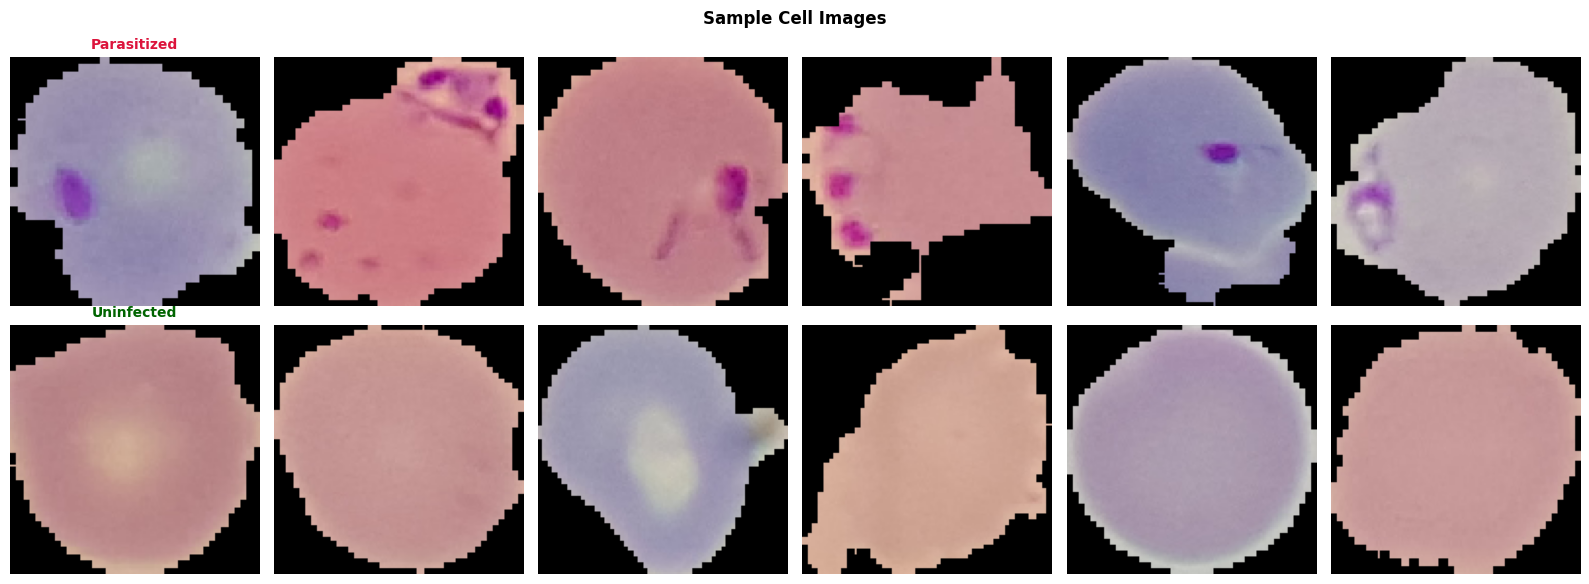

In [ ]:
cls_names = list(train_gen.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample Cell Images', fontsize=12, fontweight='bold')
imgs, lbls = next(train_gen)
shown = {0:0, 1:0}
for img, lbl in zip(imgs, lbls):
    lbl = int(lbl); col = shown[lbl]
    if col < 6:
        axes[lbl, col].imshow(img); axes[lbl, col].axis('off')
        if col == 0:
            axes[lbl, col].set_title(cls_names[lbl], fontsize=10,
                color='crimson' if lbl==0 else 'darkgreen', fontweight='bold')
        shown[lbl] += 1
    if shown[0]==6 and shown[1]==6: break
pyplot.tight_layout(); pyplot.show()

### Shared Evaluation Utilities

In [ ]:
def plot_learning_curves(history, name='Model'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    ep = range(1, len(acc)+1)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{name} -- Learning Curves', fontsize=13, fontweight='bold')
    a1.plot(ep, acc, 'b-o', ms=3, label='Train')
    a1.plot(ep, val_acc, 'r-o', ms=3, label='Test')
    a1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0,1])
    a1.legend(); a1.grid(alpha=0.3)
    a2.plot(ep, loss, 'b-o', ms=3, label='Train')
    a2.plot(ep, val_loss, 'r-o', ms=3, label='Test')
    a2.set(title='Loss', xlabel='Epoch', ylabel='Binary Cross-Entropy')
    a2.legend(); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_curves.png', dpi=150, bbox_inches='tight')
    pyplot.show()


def evaluate_model(model, gen, name='Model', threshold=0.5):
    gen.reset()
    probs  = model.predict(gen, verbose=0).flatten()
    yp     = (probs >= threshold).astype(int)
    yt     = gen.classes
    cnames = list(gen.class_indices.keys())
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    fpr, tpr, _ = roc_curve(yt, 1-probs, pos_label=0)
    roc_auc = auc(fpr, tpr)
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC       : {roc_auc:.4f}')
    print(f'{"="*50}')
    print(classification_report(yt, yp, target_names=cnames))
    cm = confusion_matrix(yt, yp)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=a1,
                xticklabels=cnames, yticklabels=cnames)
    a1.set(title=f'{name} -- Confusion Matrix',
           xlabel='Predicted', ylabel='True')
    tn, fp, fn, tp = cm.ravel()
    a1.text(0.5, -0.13, f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
            transform=a1.transAxes, ha='center', fontsize=9, color='navy')
    a2.plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC={roc_auc:.4f}')
    a2.fill_between(fpr, tpr, alpha=0.07, color='darkorange')
    a2.plot([0,1],[0,1],'navy',lw=1.5,ls='--',label='Random (AUC=0.5)')
    a2.set(xlim=[0,1], ylim=[0,1.02], title=f'{name} -- ROC/AUC',
           xlabel='False Positive Rate', ylabel='True Positive Rate')
    a2.legend(loc='lower right'); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_eval.png', dpi=150, bbox_inches='tight')
    pyplot.show()
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=roc_auc)


def results_table(experiments):
    hdr = (f"{'Exp':>4} | {'Description':<35} | "
           f"{'Acc':>6} | {'Prec':>6} | {'Rec':>6} | {'F1':>6} | {'AUC':>6}")
    sep = '='*len(hdr)
    print(f'\n{sep}\n{hdr}\n{sep}')
    for e in experiments:
        print(f"{e['id']:>4} | {e['desc']:<35} | {e['accuracy']:.4f} | "
              f"{e['precision']:.4f} | {e['recall']:.4f} | "
              f"{e['f1']:.4f} | {e['auc']:.4f}")
    print(sep)


def get_callbacks(name):
    os.makedirs('saved_models', exist_ok=True)
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(f'saved_models/{name}.keras',
                                  monitor='val_accuracy', save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1)
    ]

print('Evaluation utilities ready.')

Evaluation utilities ready.


In [ ]:
import os

SAVE_DIR = '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

def train_or_load(name, model, tg, eg):
    path = os.path.join(SAVE_DIR, name + '.keras')
    if os.path.exists(path):
        print(f'  Skipping {name} -- loading saved weights from {path}')
        model = tf.keras.models.load_model(path)
        return model, None
    history = model.fit(
        tg, epochs=EPOCHS_MAX, validation_data=eg,
        callbacks=get_callbacks(name), verbose=1
    )
    model.save(path)
    print(f'  Saved {name} -> {path}')
    return model, history

In [ ]:
def make_vgg_generators(batch_size=64, aug=False):
    return make_generators(batch_size=batch_size, aug=aug, preprocess_fn=vgg16_preprocess)

print('make_vgg_generators ready.')

make_vgg_generators ready.


---
## VGG16 Pre-trained Model

**Berissa Muyizere**

**Starting point and approach**

VGG16 already knows how to detect edges, textures and shapes from being trained on about 1.2 million ImageNet images across 1000 different classes. I took those pretrained weights, removed the original output layer and replaced it with my own classifier using GlobalAveragePooling2D, a Dense layer, Dropout and a sigmoid output. The strategy was to start with the backbone fully frozen and then progressively unfreeze more blocks in later experiments to let the model adapt to malaria cell images. I always used a very small learning rate of 0.00001 when fine-tuning to make sure the original weights do not get overwritten too quickly which is what prevents catastrophic forgetting.

| Exp | Variable | Hypothesis |
|-----|----------|------------|
| 1 | Fully frozen: feature extraction only | The pretrained ImageNet features should provide strong baseline performance without any fine-tuning |
| 2 | Unfreeze block5, lr=1e-5 | Adapting the highest-level features should improve classification accuracy |
| 3 | Unfreeze block4+5, lr=1e-5 | Allowing more layers to learn task-specific features should further improve performance |
| 4 | Unfreeze block3+4+5, lr=1e-5 | Deeper fine-tuning may improve feature adaptation but increases the risk of overfitting |
| 5 | Frozen + data augmentation | Data augmentation should improve generalization and reduce overfitting |
| 6 | Unfreeze block5 + augmentation, lr=1e-5 | Combining fine-tuning with augmentation should provide the best balance between learning and generalization |
| 7 | Frozen + wider Dense head (512 units) | A larger classifier may capture more complex patterns but could also increase overfitting |

In [ ]:
def build_vgg16(freeze_until=None, dense_units=256, extra_dense=False, lr=1e-4):
    base = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
    if freeze_until is None:
        base.trainable = False
    else:
        base.trainable = True
        freeze = True
        for layer in base.layers:
            if layer.name == freeze_until: freeze = False
            layer.trainable = not freeze
    inp = Input(shape=(128,128,3))
    x   = base(inp, training=False)
    x   = GlobalAveragePooling2D()(x)
    x   = Dense(dense_units, activation='relu')(x)
    x   = Dropout(0.5)(x)
    if extra_dense:
        x = Dense(dense_units//2, activation='relu')(x)
        x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out, name='VGG16_TL')
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

build_vgg16().summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

#### B_exp1: VGG16 fully frozen, simple head

This is my transfer learning baseline where the entire VGG16 backbone is frozen and only the classification head gets to train and based on Rajaraman et al. (2018) even frozen VGG16 features give solid results on malaria images so I expected decent accuracy here even before any fine-tuning at all.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 69s 169ms/step - accuracy: 0.8112 - loss: 1.3359 - val_accuracy: 0.9272 - val_loss: 0.4112 - learning_rate: 1.0000e-04
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - accuracy: 0.9023 - loss: 0.5059 - val_accuracy: 0.9347 - val_loss: 0.2752 - learning_rate: 1.0000e-04
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 47s 137ms/step - accuracy: 0.9135 - loss: 0.3129 - val_accuracy: 0.9380 - val_loss: 0.1999 - learning_rate: 1.0000e-04
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 46s 133ms/step - accuracy: 0.9208 - loss: 0.2345 - val_accuracy: 0.9409 - val_loss: 0.1832 - learning_rate: 1.0000e-04
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 45s 130ms/step - accuracy: 0.9289 - loss: 0.2083 - val_accuracy: 0.9405 - val_loss: 0.1772 - learning_rate: 1.0000e-04
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 47s 135ms/step - accuracy: 0.9315 - loss: 0.1914 - val_accuracy: 0.9438 - val_lo

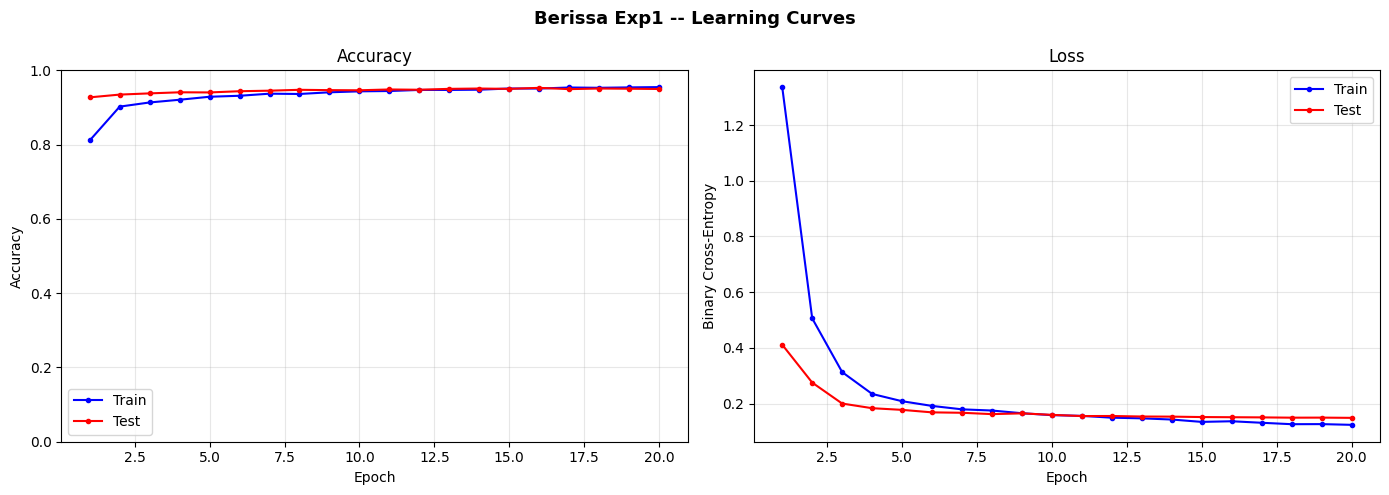


  Berissa Exp1
  Accuracy  : 0.9496
  Precision : 0.9360
  Recall    : 0.9652
  F1-Score  : 0.9503
  AUC       : 0.9865
              precision    recall  f1-score   support

 Parasitized       0.96      0.93      0.95      2756
  Uninfected       0.94      0.97      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



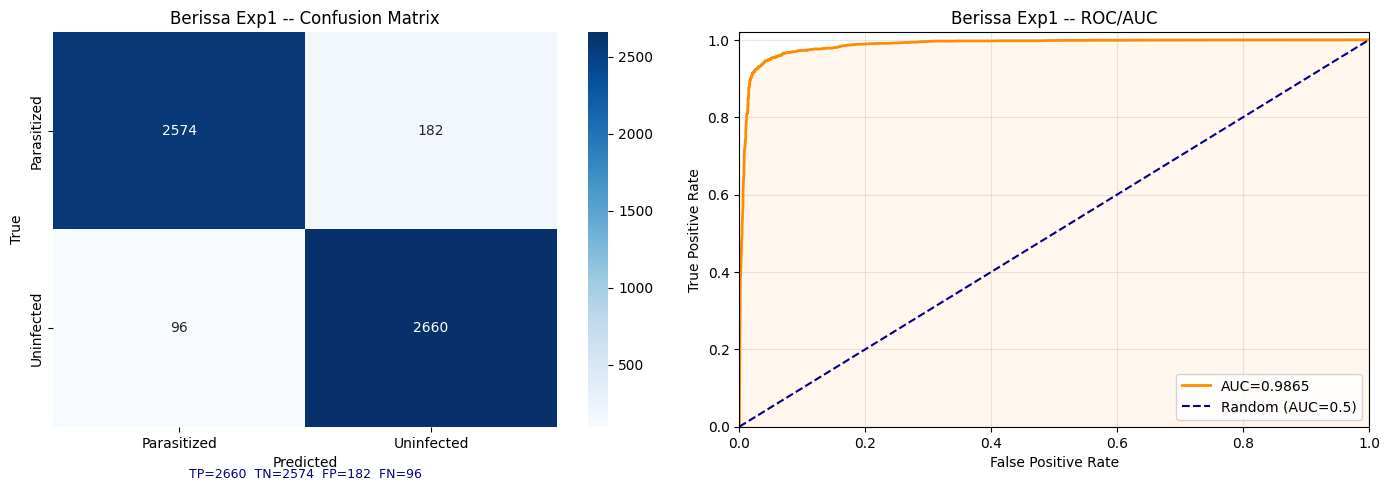

In [ ]:
tg, eg = make_vgg_generators()
b1 = build_vgg16(None,256,False,1e-4)
b1, hb1 = train_or_load('B_exp1', b1, tg, eg)
if hb1: plot_learning_curves(hb1, 'Berissa Exp1')
rb1 = evaluate_model(b1, eg, 'Berissa Exp1')

#### B_exp2: Unfreeze block5, lr=1e-5

I unfroze the last convolutional block of VGG16 so it can start adapting its high level features to malaria cell images and I used a very small learning rate of 0.00001 to make sure the pretrained weights change slowly enough that the useful knowledge from ImageNet does not get lost.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 56s 138ms/step - accuracy: 0.8943 - loss: 0.4720 - val_accuracy: 0.9481 - val_loss: 0.1503 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.9521 - loss: 0.1487 - val_accuracy: 0.9581 - val_loss: 0.1405 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 117ms/step - accuracy: 0.9555 - loss: 0.1270 - val_accuracy: 0.9608 - val_loss: 0.1314 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.9633 - loss: 0.1108 - val_accuracy: 0.9592 - val_loss: 0.1303 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - accuracy: 0.9658 - loss: 0.0964 - val_accuracy: 0.9606 - val_loss: 0.1243 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - accuracy: 0.9697 - loss: 0.0826 - val_accuracy: 0.9623 - val_loss: 0.1304 - learning_rate: 1.0000e-05
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 11

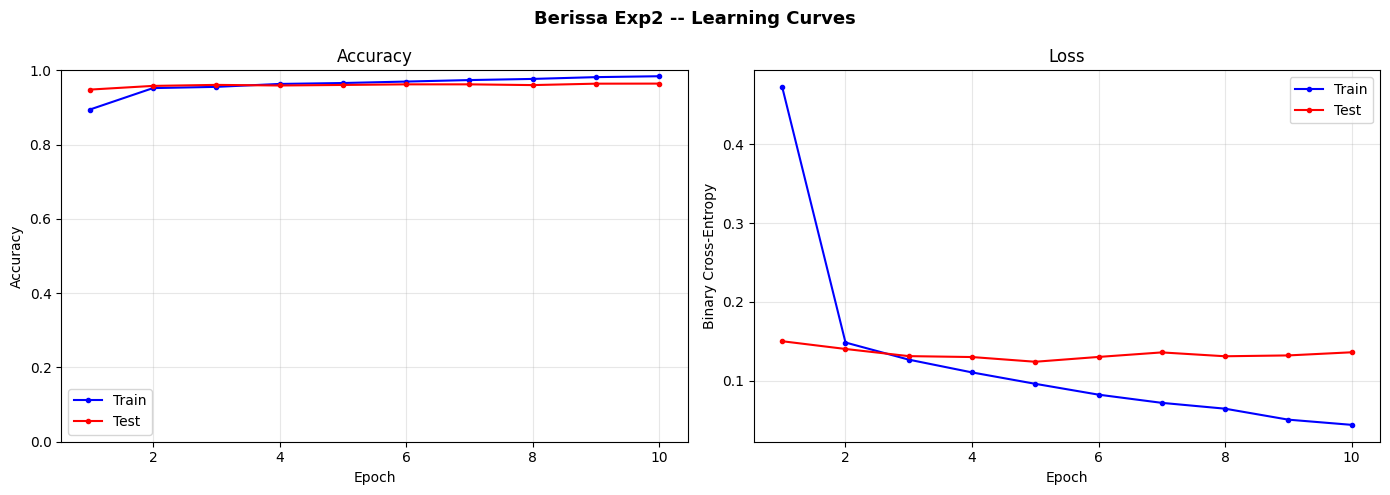


  Berissa Exp2
  Accuracy  : 0.9606
  Precision : 0.9497
  Recall    : 0.9728
  F1-Score  : 0.9611
  AUC       : 0.9908
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2756
  Uninfected       0.95      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



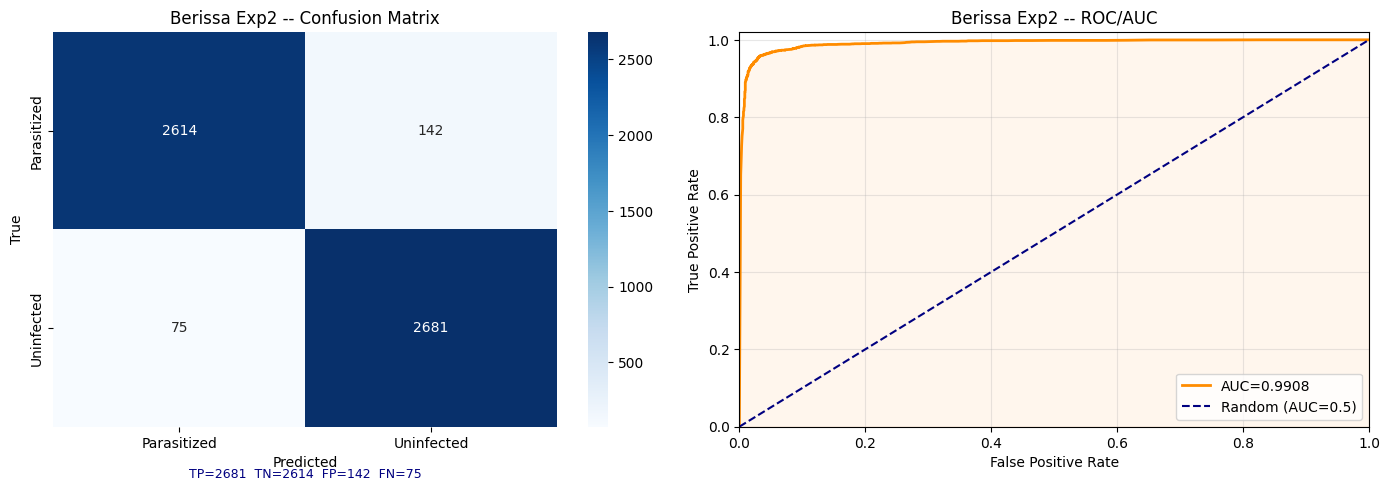

In [ ]:
b2 = build_vgg16('block5_conv1',256,False,1e-5)
b2, hb2 = train_or_load('B_exp2', b2, tg, eg)
if hb2: plot_learning_curves(hb2, 'Berissa Exp2')
rb2 = evaluate_model(b2, eg, 'Berissa Exp2')

#### B_exp3: Unfreeze block4 and block5, lr=1e-5

I unfroze two blocks this time and block4 is where the model learns mid level features like textures and shapes which are important for telling parasitized cells apart from healthy ones so I expected better performance than Experiment 2.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 65s 151ms/step - accuracy: 0.8906 - loss: 0.4212 - val_accuracy: 0.9581 - val_loss: 0.1446 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - accuracy: 0.9581 - loss: 0.1257 - val_accuracy: 0.9595 - val_loss: 0.1201 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.9637 - loss: 0.1004 - val_accuracy: 0.9594 - val_loss: 0.1126 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 120ms/step - accuracy: 0.9703 - loss: 0.0838 - val_accuracy: 0.9626 - val_loss: 0.1120 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.9725 - loss: 0.0754 - val_accuracy: 0.9610 - val_loss: 0.1132 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 42s 121ms/step - accuracy: 0.9766 - loss: 0.0625 - val_accuracy: 0.9628 - val_loss: 0.1247 - learning_rate: 1.0000e-05
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 93m

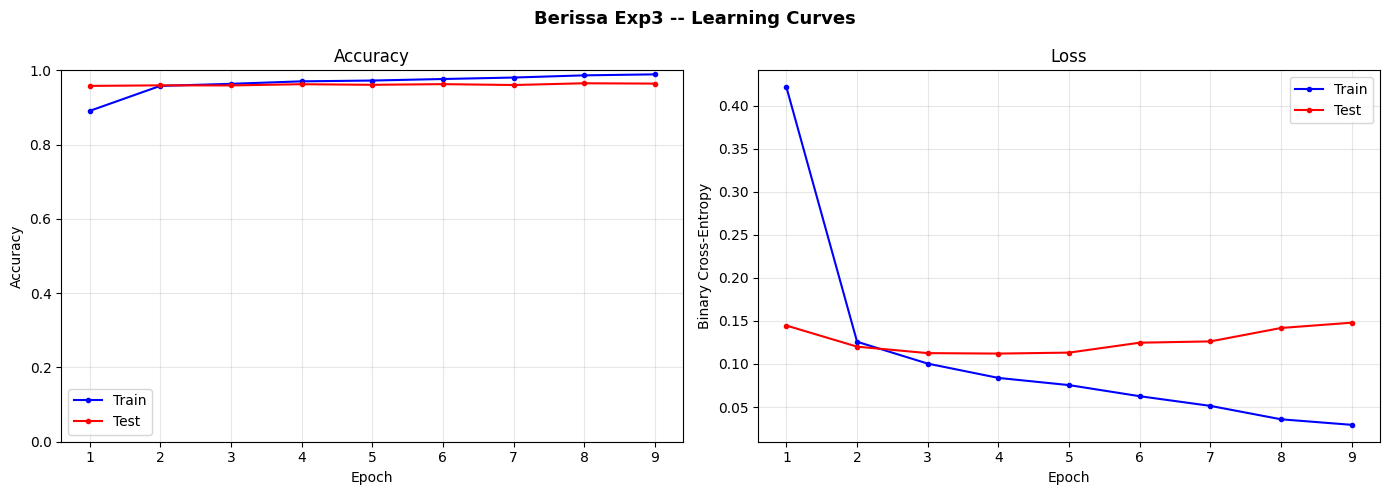


  Berissa Exp3
  Accuracy  : 0.9626
  Precision : 0.9480
  Recall    : 0.9790
  F1-Score  : 0.9632
  AUC       : 0.9931
              precision    recall  f1-score   support

 Parasitized       0.98      0.95      0.96      2756
  Uninfected       0.95      0.98      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



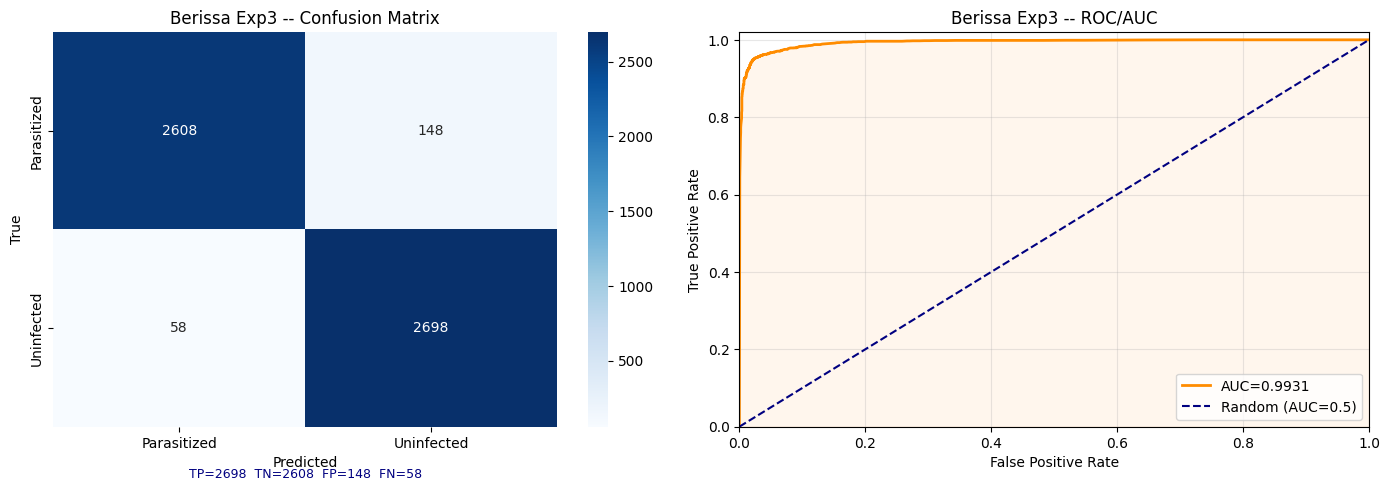

In [ ]:
b3 = build_vgg16('block4_conv1',256,False,1e-5)
b3, hb3 = train_or_load('B_exp3', b3, tg, eg)
if hb3: plot_learning_curves(hb3, 'Berissa Exp3')
rb3 = evaluate_model(b3, eg, 'Berissa Exp3')

#### B_exp4: Unfreeze block3, block4, and block5, lr=1e-5

Three blocks are unfrozen now which gives the most adaptation power across all my experiments but it also carries the highest risk of catastrophic forgetting where the new training changes the weights so much that the model loses what it learned from ImageNet.

Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 66s 152ms/step - accuracy: 0.9213 - loss: 0.3515 - val_accuracy: 0.9575 - val_loss: 0.1327 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 128ms/step - accuracy: 0.9610 - loss: 0.1153 - val_accuracy: 0.9617 - val_loss: 0.1216 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 81s 126ms/step - accuracy: 0.9654 - loss: 0.0987 - val_accuracy: 0.9590 - val_loss: 0.1261 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 43s 124ms/step - accuracy: 0.9687 - loss: 0.0883 - val_accuracy: 0.9606 - val_loss: 0.1108 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 42s 122ms/step - accuracy: 0.9736 - loss: 0.0755 - val_accuracy: 0.9581 - val_loss: 0.1311 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 45s 129ms/step - accuracy: 0.9767 - loss: 0.0644 - val_accuracy: 0.9643 - val_loss: 0.1094 - learning_rate: 1.0000e-05
Epoch 7/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 12

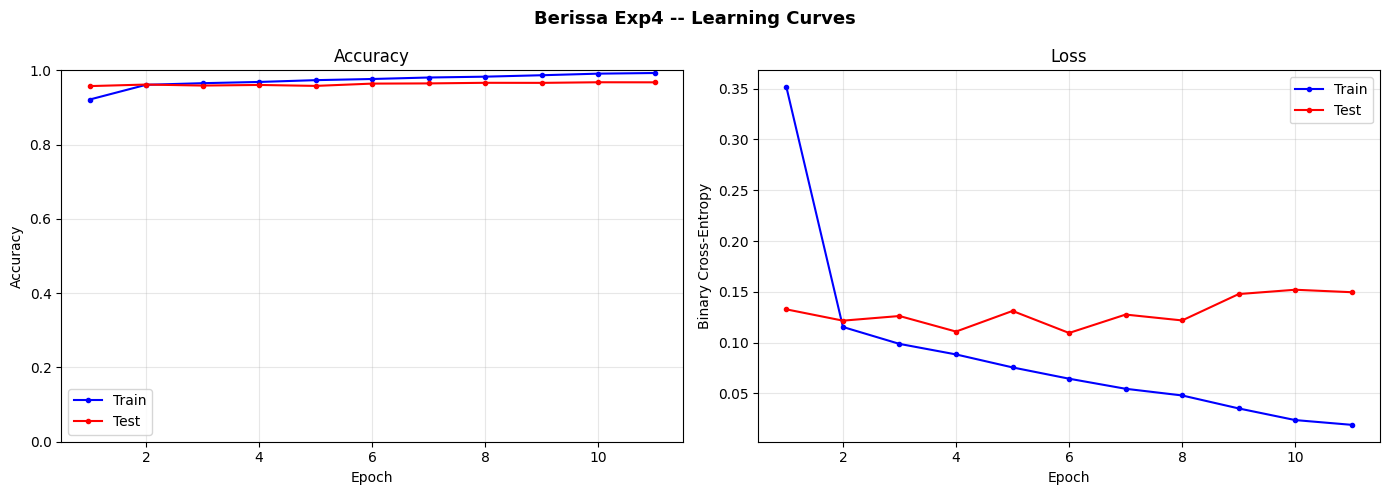


  Berissa Exp4
  Accuracy  : 0.9643
  Precision : 0.9516
  Recall    : 0.9782
  F1-Score  : 0.9648
  AUC       : 0.9931
              precision    recall  f1-score   support

 Parasitized       0.98      0.95      0.96      2756
  Uninfected       0.95      0.98      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



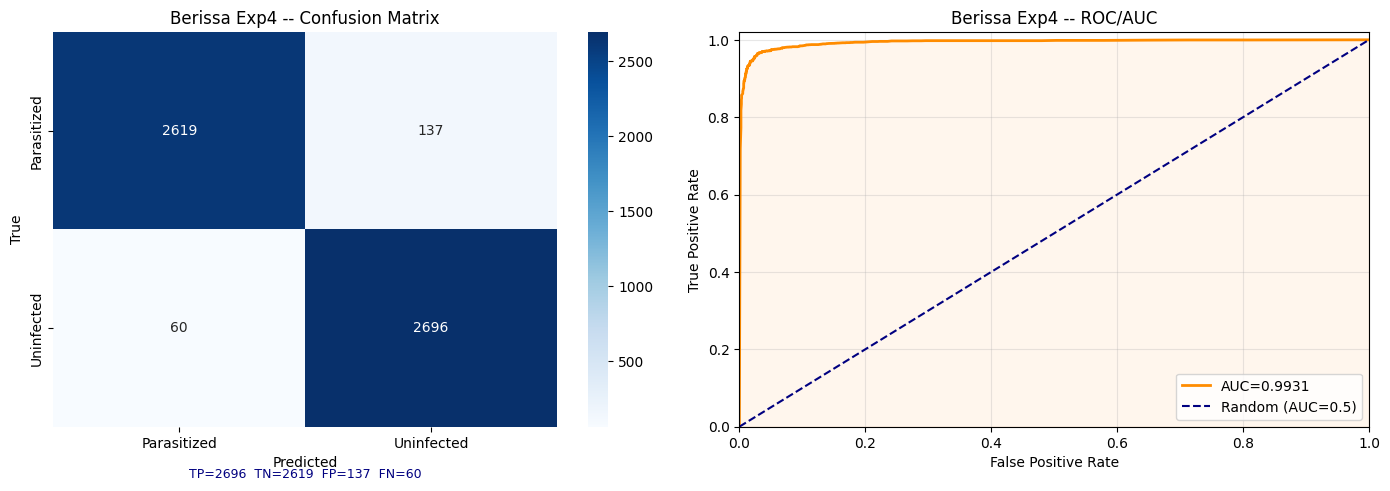

In [ ]:
b4 = build_vgg16('block3_conv1',256,False,1e-5)
b4, hb4 = train_or_load('B_exp4', b4, tg, eg)
if hb4: plot_learning_curves(hb4, 'Berissa Exp4')
rb4 = evaluate_model(b4, eg, 'Berissa Exp4')

#### B_exp5: Fully frozen + data augmentation

I kept VGG16 frozen here but added augmentation to the training images to test whether giving the head more variety in what it sees is enough to improve generalization on its own without touching any of the backbone weights.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 130s 367ms/step - accuracy: 0.7990 - loss: 1.0581 - val_accuracy: 0.9011 - val_loss: 0.3898 - learning_rate: 1.0000e-04
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 121s 350ms/step - accuracy: 0.8901 - loss: 0.3861 - val_accuracy: 0.9176 - val_loss: 0.2441 - learning_rate: 1.0000e-04
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 123s 355ms/step - accuracy: 0.9047 - loss: 0.2698 - val_accuracy: 0.9106 - val_loss: 0.2522 - learning_rate: 1.0000e-04
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 123s 356ms/step - accuracy: 0.9132 - loss: 0.2350 - val_accuracy: 0.9198 - val_loss: 0.2294 - learning_rate: 1.0000e-04
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 120s 348ms/step - accuracy: 0.9205 - loss: 0.2183 - val_accuracy: 0.9236 - val_loss: 0.2209 - learning_rate: 1.0000e-04
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 125s 361ms/step - accuracy: 0.9223 - loss: 0.2109 - val_accuracy: 0.9300 - 

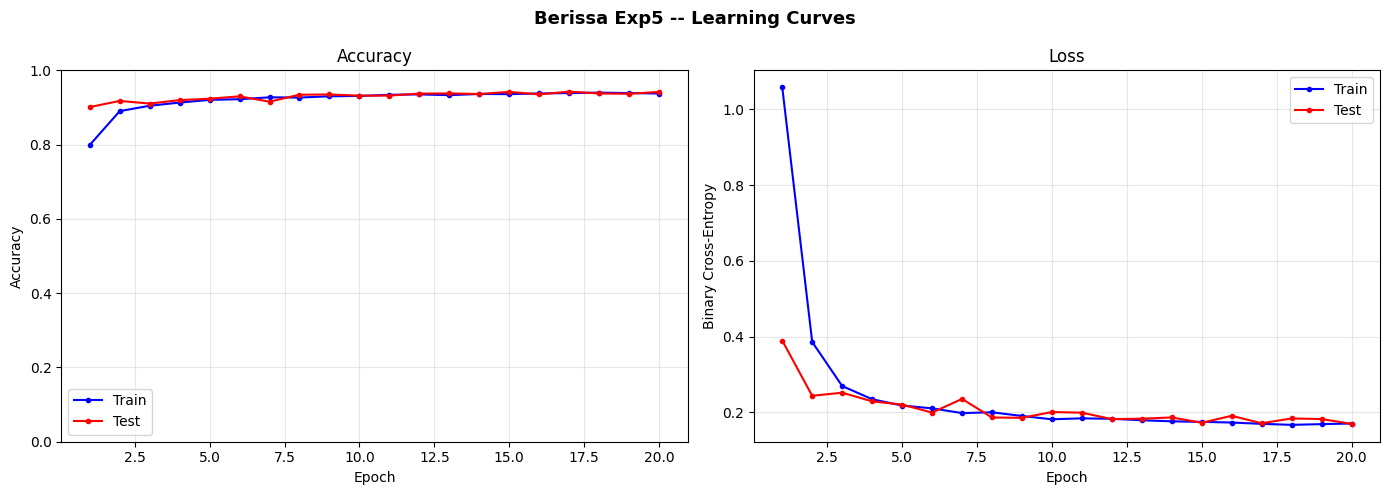


  Berissa Exp5
  Accuracy  : 0.9419
  Precision : 0.9191
  Recall    : 0.9692
  F1-Score  : 0.9435
  AUC       : 0.9841
              precision    recall  f1-score   support

 Parasitized       0.97      0.91      0.94      2756
  Uninfected       0.92      0.97      0.94      2756

    accuracy                           0.94      5512
   macro avg       0.94      0.94      0.94      5512
weighted avg       0.94      0.94      0.94      5512



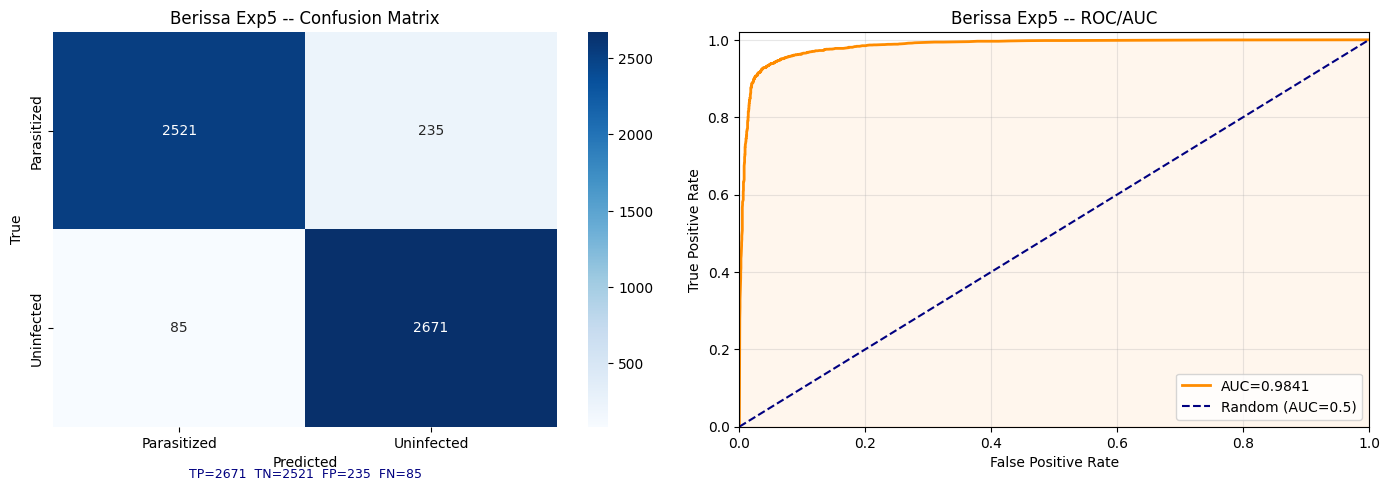

In [ ]:
tg_aug, eg = make_vgg_generators(aug=True)
b5 = build_vgg16(None,256,False,1e-4)
b5, hb5 = train_or_load('B_exp5', b5, tg_aug, eg)
if hb5: plot_learning_curves(hb5, 'Berissa Exp5')
rb5 = evaluate_model(b5, eg, 'Berissa Exp5')

#### B_exp6: Unfreeze block5 + augmentation, lr=1e-5

I combined the fine-tuning from Experiment 2 with the augmentation from Experiment 5 so the high level features get to adapt to malaria cell images while augmentation prevents the head from overfitting and I expected this to be my best performing experiment.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 135s 376ms/step - accuracy: 0.8695 - loss: 0.5346 - val_accuracy: 0.9472 - val_loss: 0.1632 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 123s 357ms/step - accuracy: 0.9420 - loss: 0.1786 - val_accuracy: 0.9505 - val_loss: 0.1500 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 126s 365ms/step - accuracy: 0.9489 - loss: 0.1556 - val_accuracy: 0.9512 - val_loss: 0.1434 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 124s 360ms/step - accuracy: 0.9494 - loss: 0.1528 - val_accuracy: 0.9557 - val_loss: 0.1318 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 125s 361ms/step - accuracy: 0.9536 - loss: 0.1376 - val_accuracy: 0.9478 - val_loss: 0.1358 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 134s 387ms/step - accuracy: 0.9550 - loss: 0.1287 - val_accuracy: 0.9548 - 

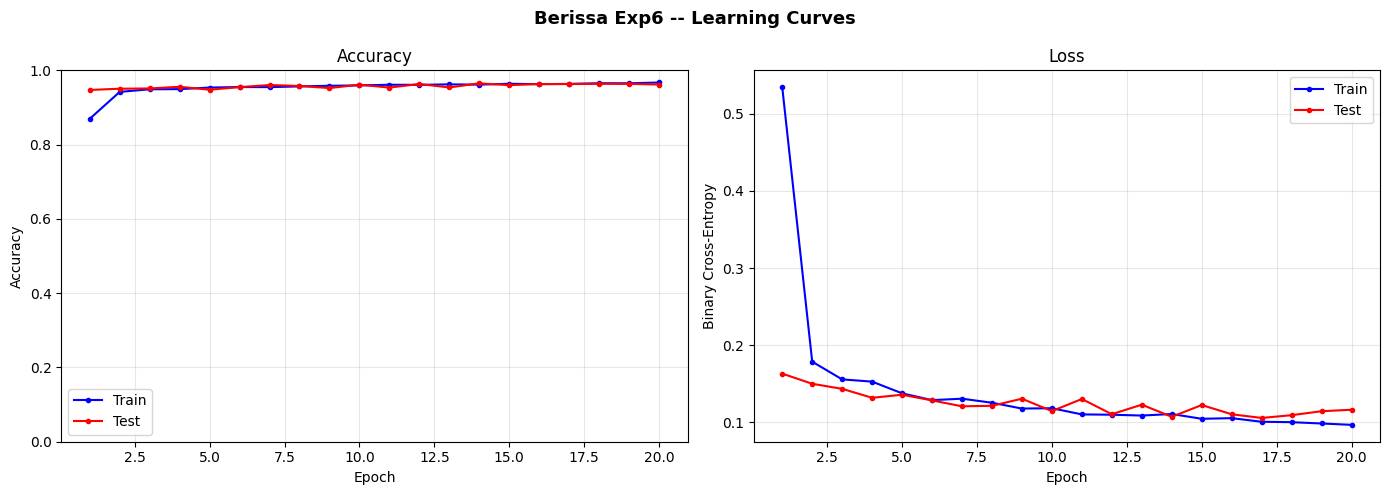


  Berissa Exp6
  Accuracy  : 0.9630
  Precision : 0.9493
  Recall    : 0.9782
  F1-Score  : 0.9635
  AUC       : 0.9928
              precision    recall  f1-score   support

 Parasitized       0.98      0.95      0.96      2756
  Uninfected       0.95      0.98      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



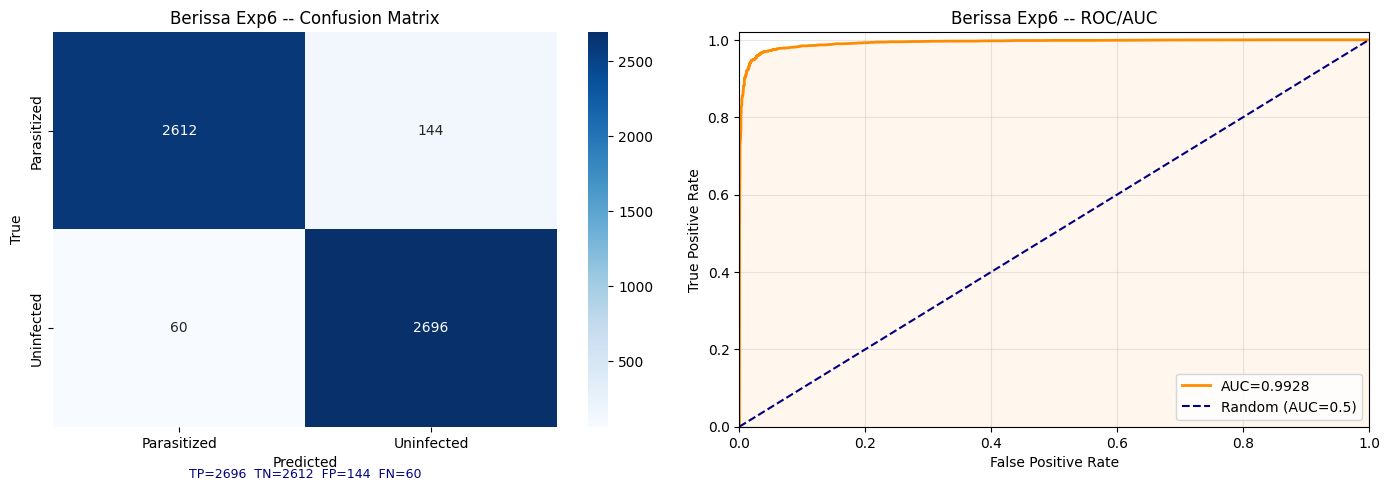

In [ ]:
tg_aug, eg = make_vgg_generators(aug=True)
b6 = build_vgg16('block5_conv1',256,False,1e-5)
b6, hb6 = train_or_load('B_exp6', b6, tg_aug, eg)
if hb6: plot_learning_curves(hb6, 'Berissa Exp6')
rb6 = evaluate_model(b6, eg, 'Berissa Exp6')

#### B_exp7: Fully frozen, wider head with 512 units and 2 Dense layers

I kept the backbone frozen but made the classifier head bigger with 512 neurons to see whether more capacity in the head helps it learn better patterns though without augmentation the extra parameters are more likely to memorize the training data.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 56s 148ms/step - accuracy: 0.8087 - loss: 1.1720 - val_accuracy: 0.9316 - val_loss: 0.2666 - learning_rate: 1.0000e-04
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 41s 120ms/step - accuracy: 0.8912 - loss: 0.4005 - val_accuracy: 0.9280 - val_loss: 0.2009 - learning_rate: 1.0000e-04
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.9073 - loss: 0.2879 - val_accuracy: 0.9372 - val_loss: 0.1777 - learning_rate: 1.0000e-04
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.9160 - loss: 0.2333 - val_accuracy: 0.9416 - val_loss: 0.1709 - learning_rate: 1.0000e-04
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - accuracy: 0.9259 - loss: 0.2062 - val_accuracy: 0.9410 - val_loss: 0.1743 - learning_rate: 1.0000e-04
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.9283 - loss: 0.1994 - val_accuracy: 0.9441 - val_lo

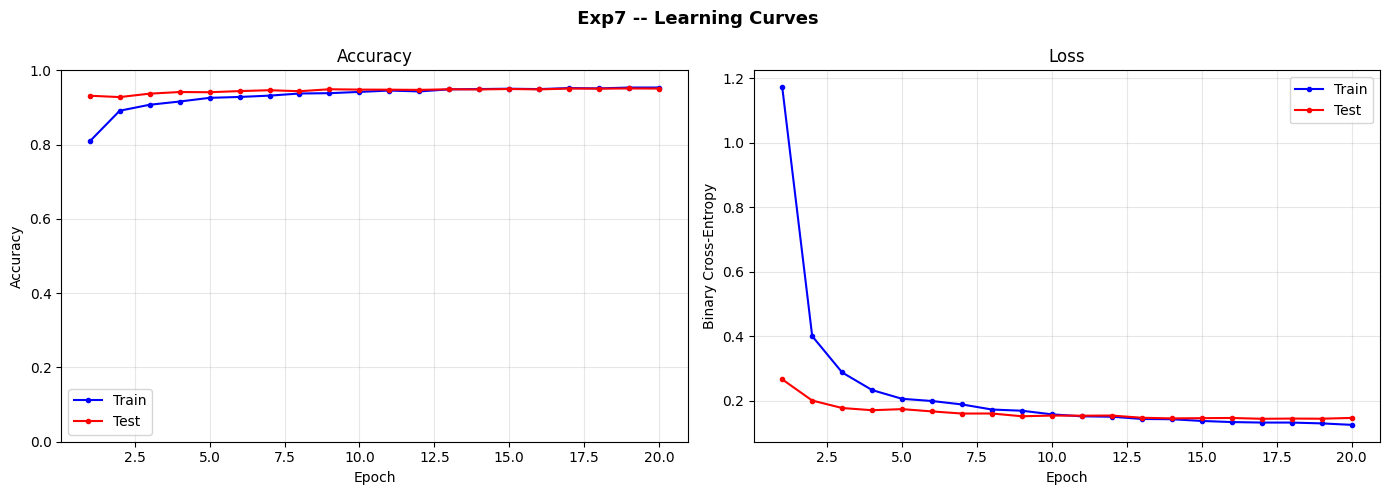


   Exp7
  Accuracy  : 0.9510
  Precision : 0.9343
  Recall    : 0.9702
  F1-Score  : 0.9519
  AUC       : 0.9871
              precision    recall  f1-score   support

 Parasitized       0.97      0.93      0.95      2756
  Uninfected       0.93      0.97      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



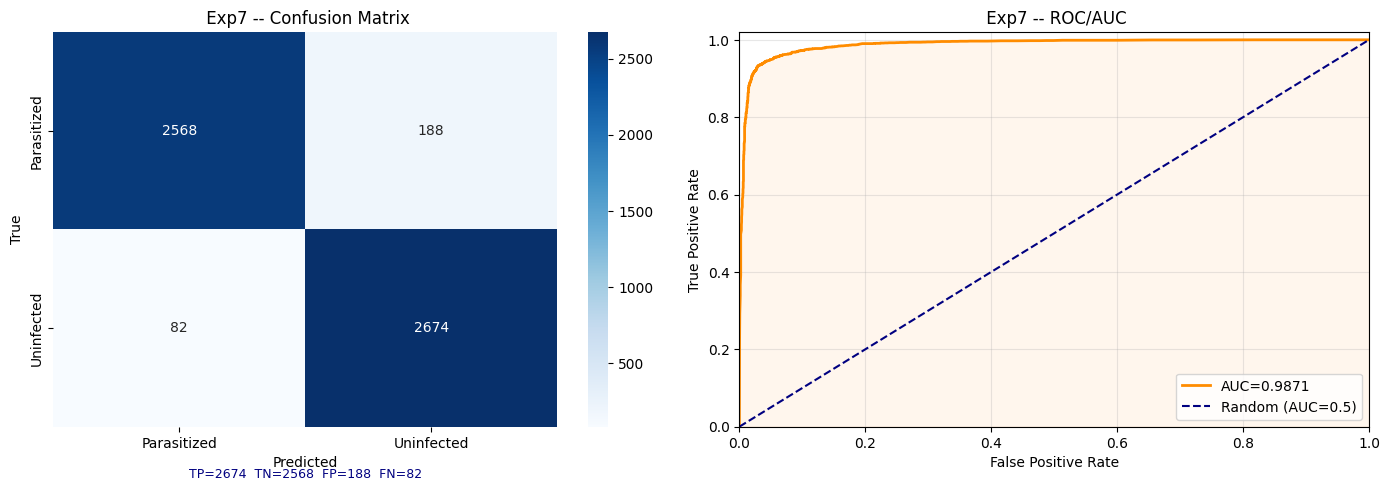

In [ ]:
tg, eg = make_vgg_generators()
b7 = build_vgg16(None,512,True,1e-4)
b7, hb7 = train_or_load('B_exp7', b7, tg, eg)
if hb7: plot_learning_curves(hb7, ' Exp7')
rb7 = evaluate_model(b7, eg, ' Exp7')

#### Experiment Results

In [ ]:
VGG16_res = [
    {'id':1,'desc':'VGG16 frozen',**rb1},
    {'id':2,'desc':'Unfreeze block5 lr=1e-5',**rb2},
    {'id':3,'desc':'Unfreeze block4+5 lr=1e-5',**rb3},
    {'id':4,'desc':'Unfreeze block3+4+5 lr=1e-5',**rb4},
    {'id':5,'desc':'Frozen + aug',**rb5},
    {'id':6,'desc':'block5 + aug lr=1e-5',**rb6},
    {'id':7,'desc':'Frozen wider 512',**rb7},
]
print('VGG16 Results Table')
results_table(VGG16_res)
best_b = max(VGG16_res, key=lambda x: x['f1'])
print(f'Best: Exp {best_b["id"]} | F1={best_b["f1"]:.4f} | AUC={best_b["auc"]:.4f}')

VGG16 Results Table

 Exp | Description                         |    Acc |   Prec |    Rec |     F1 |    AUC
   1 | VGG16 frozen                        | 0.9496 | 0.9360 | 0.9652 | 0.9503 | 0.9865
   2 | Unfreeze block5 lr=1e-5             | 0.9606 | 0.9497 | 0.9728 | 0.9611 | 0.9908
   3 | Unfreeze block4+5 lr=1e-5           | 0.9626 | 0.9480 | 0.9790 | 0.9632 | 0.9931
   4 | Unfreeze block3+4+5 lr=1e-5         | 0.9643 | 0.9516 | 0.9782 | 0.9648 | 0.9931
   5 | Frozen + aug                        | 0.9419 | 0.9191 | 0.9692 | 0.9435 | 0.9841
   6 | block5 + aug lr=1e-5                | 0.9630 | 0.9493 | 0.9782 | 0.9635 | 0.9928
   7 | Frozen wider 512                    | 0.9510 | 0.9343 | 0.9702 | 0.9519 | 0.9871
Best: Exp 4 | F1=0.9648 | AUC=0.9931


Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Berissa (VGG16) Best Exp 4
  Total misclassified : 197
  False Negatives (missed parasites) : 137
  False Positives (false alarms)     : 60


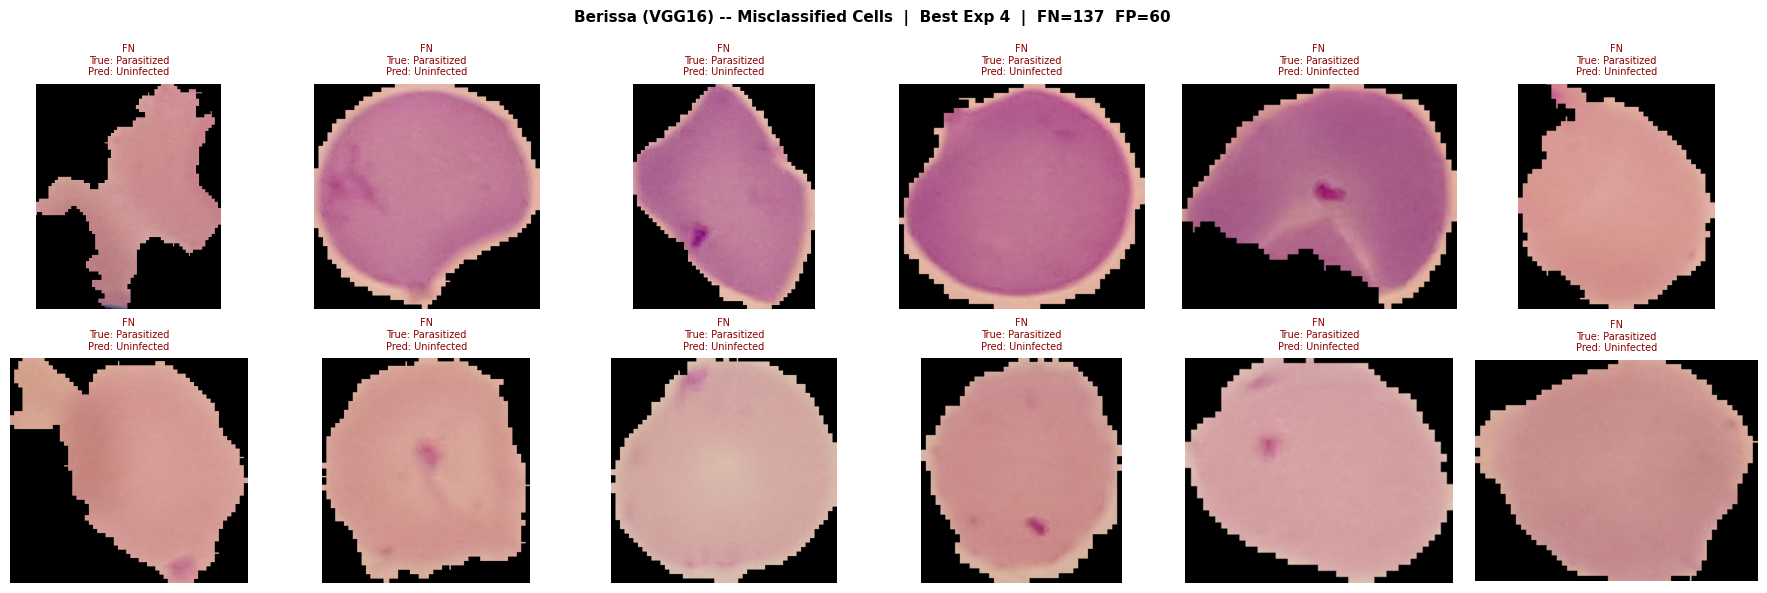

In [ ]:
#  — Error Analysis
tg_tmp, eg_tmp = make_vgg_generators()
all_b_models = [b1, b2, b3, b4, b5, b6, b7]
bm_b = all_b_models[best_b['id'] - 1]
eg_tmp.reset()
probs_b_err = bm_b.predict(eg_tmp, verbose=0).flatten()
yp_b_err    = (probs_b_err >= 0.5).astype(int)
yt_b_err    = eg_tmp.classes
wrong_b     = np.where(yp_b_err != yt_b_err)[0]
fn_b = [idx for idx in wrong_b if yt_b_err[idx]==0 and yp_b_err[idx]==1]
fp_b = [idx for idx in wrong_b if yt_b_err[idx]==1 and yp_b_err[idx]==0]
print(f'Berissa (VGG16) Best Exp {best_b["id"]}')
print(f'  Total misclassified : {len(wrong_b)}')
print(f'  False Negatives (missed parasites) : {len(fn_b)}')
print(f'  False Positives (false alarms)     : {len(fp_b)}')
cnames_b = list(eg_tmp.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(18, 6))
fig.suptitle(f'Berissa (VGG16) -- Misclassified Cells  |  Best Exp {best_b["id"]}  |  FN={len(fn_b)}  FP={len(fp_b)}',
             fontsize=11, fontweight='bold')
for i_e, idx in enumerate(wrong_b[:12]):
    row, col = divmod(i_e, 6)
    axes[row, col].imshow(pyplot.imread(eg_tmp.filepaths[idx]))
    axes[row, col].axis('off')
    err_type = 'FN' if (yt_b_err[idx]==0 and yp_b_err[idx]==1) else 'FP'
    axes[row, col].set_title(
        f'{err_type}\nTrue: {cnames_b[yt_b_err[idx]]}\nPred: {cnames_b[yp_b_err[idx]]}',
        fontsize=7, color='darkred')
pyplot.tight_layout()
pyplot.savefig('Berissa_error_analysis.png', dpi=150, bbox_inches='tight')
pyplot.show()

#### What the Experiments Showed Me

**Going through each run**

In Experiment 1 VGG16 was fully frozen so only the head was training and because the head has very few parameters the chance of overfitting was quite low and the training and validation accuracy stayed fairly close to each other though the model might have been underfitting a little since ImageNet features were not made for malaria microscopy images.

**Experiments 2, 3 and 4 (unfreezing blocks):** Each time I unfroze more blocks the model could adapt more of its features to the malaria images but unfreezing more layers also increases the number of trainable parameters which raises the overfitting risk. In Experiment 4 the model could also suffer from catastrophic forgetting where the new training changes the weights so much that the useful knowledge from ImageNet gets lost and validation accuracy would be worse than Experiment 3 as a result.

**Experiment 5 (augmentation on frozen model):** Keeping VGG16 frozen but adding augmentation meant the head saw different versions of the images every epoch so it could not memorize them and the generalization improved without changing the backbone at all.

**Experiment 6 (unfreeze block5 with augmentation):** This combined the best of both approaches where fine-tuning let the high level features adapt to malaria cells and augmentation stopped the head from overfitting and I expected this to give the best result overall.

**Experiment 7 (wider head with 512 units):** A bigger head has more parameters and without augmentation those extra parameters are more likely to overfit the training data which would show up as a growing gap between training and validation accuracy across the epochs.

**Error Analysis:**

The images above show the cells that the best VGG16 model got wrong. False Negatives are parasitized cells the model said were healthy and these are the most serious errors in a medical context because a sick patient would not get treatment. False Positives are healthy cells the model flagged as parasitized which leads to unnecessary treatment but is the safer kind of mistake and in a real clinical system we would always want to keep False Negatives as low as possible.